# Two-orbital gap equation examples

This notebook solves the projected linearized gap equation for two selectable two-orbital lattice examples. The original model uses

$$h_{orb}(\mathbf{k})=d_x(\mathbf{k})\tau_x+d_z(\mathbf{k})\tau_z,$$

while the second model uses

$$h_{orb}(\mathbf{k})=h_0(\mathbf{k})\tau_0+h_1(\mathbf{k})\tau_1+h_3(\mathbf{k})\tau_3,$$

and the two pairing channels in the displayed equation, `Delta_tx` and `Delta_ty`, do not mix. Therefore the full two-channel problem is block diagonal and can be solved by diagonalizing one symmetry-constrained single-channel kernel, then remembering that every eigenvalue is copied into the second channel.

The gap equation is solved directly on a two-dimensional momentum grid:

$$\Delta(\mathbf{p})=\int_{BZ}\frac{d^2k}{(2\pi)^2}\,K(\mathbf{p},\mathbf{k};T)\Delta(\mathbf{k}).$$

No harmonic ansatz is assumed. The channel symmetry constraint, such as odd parity for a pure triplet scalar gap, is imposed before diagonalization. Harmonic overlaps are computed only after the eigenmodes are found, as diagnostics for reading the symmetry content of the numerical solution.

In this implementation, `xi_n(k)` is the selected no-order band energy measured from the Fermi level, while the interaction and coupling prefactor are

$$\chi(\mathbf{q})=\frac{\chi_0}{\xi_{corr}^{-2}+|\mathbf{q}|^2},\qquad K\propto \frac{M^2}{2}\chi(\mathbf{p}-\mathbf{k}).$$

The notebook also supports the paper-style lattice susceptibility option
$$\chi(\mathbf{q})=\frac{\chi_0}{r-J\cos(q_x/2)\cos(q_y/2)},$$
selected by `chi_model = "paper"`.


## Parameters

`GapParams` collects all parameters used by the model, kernel, and solver. The switch `model_name` selects which no-order Hamiltonian is used. The momentum grid has `Nk` points along each direction, so the single-channel kernel has dimension

$$N_{tot}\times N_{tot},\qquad N_{tot}=N_k^2.$$

The projected normal-state dispersion used in the pairing susceptibility is

$$\xi_n(\mathbf{k})=h_0(\mathbf{k})+s_n E_{\mathbf{k}},$$

where `band_sign = +1` means $s_n=+1$ and `band_sign = -1` means $s_n=-1$. For the square two-orbital model, $h_0=-\mu$ and this reduces to $\xi_\pm=\pm E_{\mathbf{k}}-\mu$. The orbital splitting is computed from the selected no-order Hamiltonian,

$$E_{\mathbf{k}}=\sqrt{h_1(\mathbf{k})^2+h_3(\mathbf{k})^2},$$

The altermagnetic/order amplitude `M_AM` is not included in `xi_n(k)`; it enters the gap equation as the prefactor $M_{AM}^2$. The correlation length `xi_corr` controls the interaction width through

$$\chi(\mathbf{q})=\frac{\chi_0}{\xi_{corr}^{-2}+|\mathbf{q}|^2}.$$

Use `chi_model = "paper"` for
$$\chi(\mathbf{q})=\frac{\chi_0}{r-J\cos(q_x/2)\cos(q_y/2)}.$$

Thus increasing `M_AM` strengthens the whole kernel, while increasing `xi_corr` makes the interaction more sharply peaked near $\mathbf{q}=0$.


In [24]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import eigs


@dataclass
class GapParams:
    # Momentum grid in the Brillouin zone [-pi, pi).  Larger Nk gives a better integral.
    Nk: int = 51

    # Select the no-order band Hamiltonian.
    #   "square_two_orbital": old model, h0=-mu, h1=2t1(cos kx+cos ky), h3=4t2 sin kx sin ky.
    #   "lieb_lattice": Lieb lattice model from the note, h0/h1/h3 defined below.
    model_name: str = "lieb_lattice"

    # Parameters for the original square-lattice two-orbital Hamiltonian.
    t1: float = 0.3
    t2: float = -0.2

    # Parameters for the Lieb lattice Hamiltonian.
    t: float = 1.0
    tp_a: float = -0.3
    tp_b: float = 0.2
    M_AM: float = 3  # enters the gap kernel as M_AM^2; xi_n(k) below still excludes the AM term.

    # Projected band dispersion xi_n(k) = h0(k) + band_sign * Ek.
    mu: float = 4.0
    band_sign: int = 1
    T: float = 0.05

    # Susceptibility chi(q).  Options: "continuum", "lattice", or "paper".
    chi0: float = 1.0
    xi_corr: float = 5.29
    r: float = 1.0  # used by the optional lattice and paper susceptibilities
    J: float = 1.0/1.0753 # used by chi_model="paper"
    chi_model: str = "continuum"  # "continuum", "lattice", or "paper"

    # Overall factor in the displayed equation: Delta = (M^2/2) integral ... Delta.
    kernel_prefactor: float = 1.0 / 2.0

    # Numerical details.
    orbital_eta: float = 1e-12
    xi_eta: float = 1e-10
    num_eigs: int = 8
    eigs_which: str = "LR"  # largest real part
    save_outputs: bool = True

    # Symmetry sector solved as the primary channel problem.
    #   "odd_triplet": Delta_t(-k) = -Delta_t(k), appropriate for a pure triplet scalar gap.
    #   "even_singlet": Delta_s(-k) = +Delta_s(k), appropriate for a pure singlet scalar gap.
    #   "unconstrained": diagonalize the full scalar kernel for diagnostics only.
    channel_constraint: str = "odd_triplet"


params = GapParams()
params


GapParams(Nk=51, model_name='lieb_lattice', t1=0.3, t2=-0.2, t=1.0, tp_a=-0.3, tp_b=0.2, M_AM=3, mu=4.0, band_sign=1, T=0.05, chi0=1.0, xi_corr=5.29, r=1.0, J=0.9299730307821074, chi_model='continuum', kernel_prefactor=0.5, orbital_eta=1e-12, xi_eta=1e-10, num_eigs=8, eigs_which='LR', save_outputs=True, channel_constraint='odd_triplet')

## Band Model And Bare Fermi Surface

There are two no-order band Hamiltonians available. Select them by setting `params.model_name`.

For `model_name = "square_two_orbital"`, the Hamiltonian is

$$h_{orb}(\mathbf{k})=-\mu\tau_0+d_x(\mathbf{k})\tau_x+d_z(\mathbf{k})\tau_z,$$

with

$$d_x(\mathbf{k})=2t_1(\cos k_x+\cos k_y),\qquad d_z(\mathbf{k})=4t_2\sin k_x\sin k_y.$$

For `model_name = "lieb_lattice"` (Lieb lattice model), the Hamiltonian is

$$h_{orb}(\mathbf{k})=h_0(\mathbf{k})\tau_0+h_1(\mathbf{k})\tau_1+h_3(\mathbf{k})\tau_3,$$

where

$$h_0(\mathbf{k})=-(t'_a+t'_b)(\cos k_x+\cos k_y)-\mu,$$

$$h_1(\mathbf{k})=-4t\cos\frac{k_x}{2}\cos\frac{k_y}{2},\qquad h_3(\mathbf{k})=-(t'_a-t'_b)(\cos k_x-\cos k_y).$$

The corresponding no-order band energies are

$$\epsilon_\pm(\mathbf{k})=h_0(\mathbf{k})\pm E_{\mathbf{k}},\qquad E_{\mathbf{k}}=\sqrt{h_1(\mathbf{k})^2+h_3(\mathbf{k})^2}.$$

The helper `plot_fermi_surface_no_order` draws the zero contours

$$\xi_+(\mathbf{k})=h_0(\mathbf{k})+E_{\mathbf{k}}=0,\qquad \xi_-(\mathbf{k})=h_0(\mathbf{k})-E_{\mathbf{k}}=0.$$

These are the bare Fermi surfaces before including the altermagnetic/order term. The gray contours in the plot are constant-$E_{\mathbf{k}}$ contours and should not move when only `mu` is changed; the red/blue Fermi-surface contours move because their zero condition contains `mu`.


In [25]:
tau0 = np.array([[1, 0], [0, 1]], dtype=complex)
tau1 = np.array([[0, 1], [1, 0]], dtype=complex)
tau2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
tau3 = np.array([[1, 0], [0, -1]], dtype=complex)
sigma0 = tau0.copy()
sigma3 = tau3.copy()


def make_grid(p: GapParams):
    x = np.linspace(-np.pi, np.pi, p.Nk, endpoint=False)
    y = np.linspace(-np.pi, np.pi, p.Nk, endpoint=False)
    qx, qy = np.meshgrid(x, y, indexing="xy")
    vqx = qx.reshape(-1)
    vqy = qy.reshape(-1)
    dxy = (2.0 * np.pi / p.Nk) ** 2
    integral_prefactor = dxy / (2.0 * np.pi) ** 2
    return x, y, qx, qy, vqx, vqy, dxy, integral_prefactor


def wrap_bz(q):
    return (q + np.pi) % (2.0 * np.pi) - np.pi


def model_label(p: GapParams):
    if p.model_name == "square_two_orbital":
        return "square two-orbital"
    if p.model_name == "lieb_lattice":
        return "Lieb lattice model"
    return p.model_name


def orbital_component_labels(p: GapParams):
    if p.model_name == "lieb_lattice":
        return "h_1(k)", "h_3(k)"
    return "d_x(k)", "d_z(k)"


def orbital_components(kx, ky, p: GapParams):
    """Return h0(k), h1/dx(k), and h3/dz(k) for the selected no-order Hamiltonian."""
    kx, ky = np.broadcast_arrays(kx, ky)
    if p.model_name == "square_two_orbital":
        h0 = np.full_like(kx, -p.mu, dtype=float)
        dx = 2.0 * p.t1 * (np.cos(kx) + np.cos(ky))
        dz = 4.0 * p.t2 * np.sin(kx) * np.sin(ky)
    elif p.model_name == "lieb_lattice":
        h0 = -(p.tp_a + p.tp_b) * (np.cos(kx) + np.cos(ky)) - p.mu
        dx = -4.0 * p.t * np.cos(0.5 * kx) * np.cos(0.5 * ky)
        dz = -(p.tp_a - p.tp_b) * (np.cos(kx) - np.cos(ky))
    else:
        raise ValueError("model_name must be 'square_two_orbital' or 'lieb_lattice'")
    return h0, dx, dz


def dx_dz(kx, ky, p: GapParams):
    """Backward-compatible helper: returns the two nontrivial orbital components only."""
    _, dx, dz = orbital_components(kx, ky, p)
    return dx, dz


def orbital_energy(dx, dz, p: GapParams):
    return np.sqrt(dx * dx + dz * dz + p.orbital_eta ** 2)


def H_full(kx, ky, p: GapParams):
    h0, dx, dz = orbital_components(kx, ky, p)
    h_orb = h0 * tau0 + dx * tau1 + dz * tau3
    return np.kron(h_orb, sigma0) + p.M_AM * np.kron(tau3, sigma3)


def xi_band(h0, Ek, p: GapParams):
    return h0 + p.band_sign * Ek


def pair_factor(xi, p: GapParams):
    # tanh(xi / 2T) / (2 xi), with the xi -> 0 limit 1 / (4T).
    out = np.empty_like(xi, dtype=float)
    small = np.abs(xi) < p.xi_eta
    out[small] = 1.0 / (4.0 * p.T)
    out[~small] = np.tanh(xi[~small] / (2.0 * p.T)) / (2.0 * xi[~small])
    return out


def susceptibility(qx, qy, p: GapParams):
    qx = wrap_bz(qx)
    qy = wrap_bz(qy)
    if p.chi_model == "continuum":
        # chi(q) = chi0 / (xi_corr^-2 + |q|^2).  q is wrapped to the shortest BZ difference.
        denom = p.xi_corr ** -2 + qx * qx + qy * qy
    elif p.chi_model == "lattice":
        denom = p.r + 2.0 - np.cos(qx) - np.cos(qy)
    elif p.chi_model == "paper":
        denom = p.r - p.J * np.cos(0.5 * qx) * np.cos(0.5 * qy)
    else:
        raise ValueError("chi_model must be 'continuum', 'lattice', or 'paper'")
    return p.chi0 / denom


def fermi_surface_data_no_order(p: GapParams, plot_grid_points=501):
    """Return xi_+(k) and xi_-(k) for the Hamiltonian without the AM/order term."""
    kx = np.linspace(-np.pi, np.pi, plot_grid_points)
    ky = np.linspace(-np.pi, np.pi, plot_grid_points)
    qx, qy = np.meshgrid(kx, ky, indexing="xy")
    h0, dx, dz = orbital_components(qx, qy, p)
    Ek = orbital_energy(dx, dz, p)
    xi_plus = h0 + Ek
    xi_minus = h0 - Ek
    return kx, ky, qx, qy, h0, Ek, xi_plus, xi_minus


def band_diagnostics(p: GapParams, plot_grid_points=501):
    _, _, _, _, h0, Ek, xi_plus, xi_minus = fermi_surface_data_no_order(p, plot_grid_points=plot_grid_points)
    selected_xi = xi_plus if p.band_sign == 1 else xi_minus
    return {
        "h0_min": float(np.min(h0)),
        "h0_max": float(np.max(h0)),
        "E_min": float(np.min(Ek)),
        "E_max": float(np.max(Ek)),
        "xi_min": float(np.min(selected_xi)),
        "xi_max": float(np.max(selected_xi)),
        "min_abs_xi": float(np.min(np.abs(selected_xi))),
        "selected_band_crosses_fs": crosses_zero(selected_xi),
        "upper_band_crosses_fs": crosses_zero(xi_plus),
        "lower_band_crosses_fs": crosses_zero(xi_minus),
    }


def print_band_diagnostics(p: GapParams):
    diag = band_diagnostics(p)
    print(f"model = {model_label(p)}")
    print(f"h0(k) range = [{diag['h0_min']:+.4e}, {diag['h0_max']:+.4e}]")
    print(f"bare E_k range = [{diag['E_min']:.4e}, {diag['E_max']:.4e}]")
    print(f"selected xi range = [{diag['xi_min']:+.4e}, {diag['xi_max']:+.4e}], min |xi| = {diag['min_abs_xi']:.4e}")
    if not diag["selected_band_crosses_fs"]:
        print("Warning: the selected band has no xi(k)=0 crossing. The tanh(xi/2T)/(2xi) factor is nearly T-independent when T << min|xi|.")
    return diag


def crosses_zero(data):
    return float(np.min(data)) <= 0.0 <= float(np.max(data))


def bare_energy_levels(p: GapParams, num_levels=12, plot_grid_points=501):
    # Constant-E_k contours.  These are independent of mu for both implemented models.
    _, _, _, _, _, Ek, _, _ = fermi_surface_data_no_order(p, plot_grid_points=plot_grid_points)
    return np.linspace(float(np.min(Ek)), float(np.max(Ek)), num_levels)


def plot_fermi_surface_no_order(p: GapParams, plot_grid_points=501, background_levels=None):
    """Plot the zero-energy contours of xi_+(k) and xi_-(k) before adding order."""
    from matplotlib.lines import Line2D

    kx, ky, qx, qy, h0, Ek, xi_plus, xi_minus = fermi_surface_data_no_order(p, plot_grid_points=plot_grid_points)
    fig, ax = plt.subplots(figsize=(4.2, 4.0), constrained_layout=True)
    handles = []

    if background_levels is None:
        background_levels = bare_energy_levels(p, num_levels=12, plot_grid_points=plot_grid_points)
    ax.contour(qx, qy, Ek, levels=background_levels, colors="0.86", linewidths=0.55)

    if crosses_zero(xi_plus):
        ax.contour(qx, qy, xi_plus, levels=[0.0], colors="crimson", linewidths=1.8)
        handles.append(Line2D([0], [0], color="crimson", lw=1.8, label=r"$\xi_+(k)=0$"))
    if crosses_zero(xi_minus):
        ax.contour(qx, qy, xi_minus, levels=[0.0], colors="royalblue", linewidths=1.8, linestyles="--")
        handles.append(Line2D([0], [0], color="royalblue", lw=1.8, ls="--", label=r"$\xi_-(k)=0$"))
    if not handles:
        ax.text(0.0, 0.0, "no FS crossing", ha="center", va="center")
    else:
        ax.legend(handles=handles, loc="upper right", frameon=False)

    ax.set_title(rf"bare Fermi surface, {model_label(p)}, $\mu={p.mu:g}$")
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_xticks([-np.pi, 0.0, np.pi])
    ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_yticks([-np.pi, 0.0, np.pi])
    ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_aspect("equal")
    return fig


x, y, qx, qy, vqx, vqy, dxy, integral_prefactor = make_grid(params)
h0_grid, dx_grid, dz_grid = orbital_components(qx, qy, params)
Ek_grid = orbital_energy(dx_grid, dz_grid, params)
print(f"Nk = {params.Nk}, Ntot = {params.Nk ** 2}, integral prefactor = {integral_prefactor:.6e}")
print(f"model = {model_label(params)}")
print(f"h0 range = [{h0_grid.min():+.4e}, {h0_grid.max():+.4e}]")
print(f"Ek range = [{Ek_grid.min():.4e}, {Ek_grid.max():.4e}]")


Nk = 51, Ntot = 2601, integral prefactor = 3.844675e-04
model = Lieb lattice model
h0 range = [-4.2000e+00, -3.8004e+00]
Ek range = [1.0000e-12, 3.9962e+00]


## Discretized Gap Kernel

For either channel, the continuum gap equation implemented here has the form

$$\Delta(\mathbf{p})=\frac{M^2}{2}\int_{BZ}\frac{d^2k}{(2\pi)^2}\,\chi(\mathbf{p}-\mathbf{k})\,C(\mathbf{p},\mathbf{k})\,F(\mathbf{k},T)\,\Delta(\mathbf{k}),$$

where the orbital coherence factor is

$$C(\mathbf{p},\mathbf{k})=1+\frac{h_3(\mathbf{k})h_3(\mathbf{p})-h_1(\mathbf{k})h_1(\mathbf{p})}{E_{\mathbf{k}}E_{\mathbf{p}}},$$

For the original square-lattice model, identify $h_1=d_x$ and $h_3=d_z$.

The BCS thermal factor is

$$F(\mathbf{k},T)=\frac{\tanh[\xi_n(\mathbf{k})/(2T)]}{2\xi_n(\mathbf{k})}.$$

The code uses the finite limit $F\to 1/(4T)$ when $|\xi_n(\mathbf{k})|$ is numerically close to zero. The interaction is

$$\chi(\mathbf{p}-\mathbf{k})=\frac{\chi_0}{\xi_{corr}^{-2}+|\mathbf{p}-\mathbf{k}|^2},$$

with the momentum transfer wrapped to the shortest Brillouin-zone difference.

On the grid, the integral becomes

$$\Delta_i=\sum_j K_{ij}\Delta_j,$$

with

$$K_{ij}=\left(\frac{M^2}{2}\right)\frac{\Delta k_x\Delta k_y}{(2\pi)^2}\,\chi(\mathbf{p}_i-\mathbf{k}_j)\,C(\mathbf{p}_i,\mathbf{k}_j)\,F(\mathbf{k}_j,T).$$

The two displayed equations for $\Delta_{t_x}$ and $\Delta_{t_y}$ have the same scalar kernel and do not mix. Therefore the full two-channel matrix is

$$K_{2ch}=\begin{pmatrix}K&0\\0&K\end{pmatrix}.$$

The notebook first projects the single-channel block `K` into the channel symmetry sector selected by `params.channel_constraint`, then diagonalizes that reduced matrix. The full two-channel eigenvalues are still exactly two-fold degenerate because `Delta_tx` and `Delta_ty` use the same constrained block. This avoids both the artificial even-parity triplet solutions and the numerical ambiguity from diagonalizing a perfectly degenerate two-channel matrix directly.

Important symmetry point: this scalar eigenproblem by itself is not yet the fermionic antisymmetry constraint. For a pure spin-triplet channel with a symmetric orbital/internal matrix, the scalar amplitude must satisfy $\Delta_t(-\mathbf{k})=-\Delta_t(\mathbf{k})$. The unconstrained scalar kernel commutes with inversion, so it has both even and odd eigenmodes. The even modes are useful diagnostics of the mathematical kernel but should not be interpreted as physical pure-triplet gaps unless another antisymmetric internal factor is present.


In [26]:
def build_single_channel_kernel(p: GapParams, verbose=True):
    x, y, qx, qy, vqx, vqy, dxy, pref = make_grid(p)
    h0v, dxv, dzv = orbital_components(vqx, vqy, p)
    Ev = orbital_energy(dxv, dzv, p)
    xiv = xi_band(h0v, Ev, p)
    fv = pair_factor(xiv, p)

    if verbose:
        print("Building one-channel kernel K(p,k) ...")

    px = vqx[:, None]
    py = vqy[:, None]
    kx = vqx[None, :]
    ky = vqy[None, :]

    chi_pk = susceptibility(px - kx, py - ky, p)
    coherence = 1.0 + (dzv[None, :] * dzv[:, None] - dxv[None, :] * dxv[:, None]) / (Ev[None, :] * Ev[:, None])
    K = p.kernel_prefactor * p.M_AM ** 2 * pref * chi_pk * coherence * fv[None, :]
    return K, (x, y, qx, qy, vqx, vqy, h0v, dxv, dzv, Ev, xiv, fv, pref)


def solve_eigenproblem(K, p: GapParams):
    dim = K.shape[0]
    if dim <= p.num_eigs + 2:
        evals, evecs = np.linalg.eig(K)
    else:
        k = min(p.num_eigs, dim - 2)
        evals, evecs = eigs(K, k=k, which=p.eigs_which)

    order = np.argsort(np.real(evals))[::-1]
    evals = evals[order][: p.num_eigs]
    evecs = evecs[:, order][:, : p.num_eigs]
    return evals, evecs


def align_phase(vec):
    idx = int(np.argmax(np.abs(vec)))
    if abs(vec[idx]) < 1e-14:
        return vec
    return vec * np.exp(-1j * np.angle(vec[idx]))


def mode_grid(vec, Nk):
    return np.real(align_phase(vec)).reshape(Nk, Nk)


def inversion_indices(Nk):
    iy, ix = np.indices((Nk, Nk))
    return (((-iy) % Nk) * Nk + ((-ix) % Nk)).reshape(-1)


def parity_components(vec, Nk):
    inv = inversion_indices(Nk)
    even = 0.5 * (vec + vec[inv])
    odd = 0.5 * (vec - vec[inv])
    return even, odd


def parity_summary(vec, Nk):
    inv = inversion_indices(Nk)
    even, odd = parity_components(vec, Nk)
    norm = float(np.sqrt(np.vdot(vec, vec).real))
    if norm < 1e-14:
        return "zero", 0.0, 0.0, 0.0
    even_weight = float(np.vdot(even, even).real / norm ** 2)
    odd_weight = float(np.vdot(odd, odd).real / norm ** 2)
    if even_weight >= odd_weight:
        label = "even"
        residual = float(np.linalg.norm(vec - vec[inv]) / norm)
    else:
        label = "odd"
        residual = float(np.linalg.norm(vec + vec[inv]) / norm)
    return label, even_weight, odd_weight, residual


def parity_rows(evals, evecs, Nk, num_modes=8):
    rows = []
    for mode in range(min(num_modes, evecs.shape[1])):
        label, even_weight, odd_weight, residual = parity_summary(evecs[:, mode], Nk)
        rows.append([
            str(mode + 1),
            f"{np.real(evals[mode]):+.6e}",
            label,
            f"{even_weight:.6f}",
            f"{odd_weight:.6f}",
            f"{residual:.2e}",
        ])
    return rows


def inversion_pairs(Nk):
    inv = inversion_indices(Nk)
    seen = np.zeros(Nk * Nk, dtype=bool)
    pairs = []
    fixed = []
    for idx, partner in enumerate(inv):
        if seen[idx]:
            continue
        if idx == partner:
            fixed.append(idx)
            seen[idx] = True
        else:
            pairs.append((idx, partner))
            seen[idx] = True
            seen[partner] = True
    return np.array(pairs, dtype=int), np.array(fixed, dtype=int)


def parity_constrained_kernel(K, Nk, parity):
    if parity not in ("even", "odd"):
        raise ValueError("parity must be 'even' or 'odd'")
    pairs, fixed = inversion_pairs(Nk)
    a = pairs[:, 0]
    b = pairs[:, 1]
    Kaa = K[np.ix_(a, a)]
    Kab = K[np.ix_(a, b)]
    Kba = K[np.ix_(b, a)]
    Kbb = K[np.ix_(b, b)]
    if parity == "odd":
        K_reduced = 0.5 * (Kaa - Kab - Kba + Kbb)
    else:
        K_pair = 0.5 * (Kaa + Kab + Kba + Kbb)
        if len(fixed) == 0:
            K_reduced = K_pair
        else:
            scale = 1.0 / np.sqrt(2.0)
            K_pair_fixed = scale * (K[np.ix_(a, fixed)] + K[np.ix_(b, fixed)])
            K_fixed_pair = scale * (K[np.ix_(fixed, a)] + K[np.ix_(fixed, b)])
            K_fixed_fixed = K[np.ix_(fixed, fixed)]
            K_reduced = np.block([[K_pair, K_pair_fixed], [K_fixed_pair, K_fixed_fixed]])
    return K_reduced, pairs, fixed


def expand_parity_eigenvectors(evecs_reduced, pairs, fixed, Nk, parity):
    if parity not in ("even", "odd"):
        raise ValueError("parity must be 'even' or 'odd'")
    evecs = np.zeros((Nk * Nk, evecs_reduced.shape[1]), dtype=evecs_reduced.dtype)
    scale = 1.0 / np.sqrt(2.0)
    pair_part = evecs_reduced[: len(pairs), :]
    if parity == "even":
        evecs[pairs[:, 0], :] = scale * pair_part
        evecs[pairs[:, 1], :] = scale * pair_part
        if len(fixed) > 0:
            evecs[fixed, :] = evecs_reduced[len(pairs) :, :]
    else:
        evecs[pairs[:, 0], :] = scale * pair_part
        evecs[pairs[:, 1], :] = -scale * pair_part
    return evecs


def constraint_to_parity(constraint):
    aliases = {
        "even": "even",
        "even_singlet": "even",
        "singlet_even": "even",
        "odd": "odd",
        "odd_triplet": "odd",
        "triplet_odd": "odd",
    }
    if constraint not in aliases:
        raise ValueError("constraint must be 'unconstrained', 'odd_triplet', or 'even_singlet'")
    return aliases[constraint]


def solve_parity_constrained_eigenproblem(K, p: GapParams, parity):
    K_reduced, pairs, fixed = parity_constrained_kernel(K, p.Nk, parity)
    evals, evecs_reduced = solve_eigenproblem(K_reduced, p)
    evecs = expand_parity_eigenvectors(evecs_reduced, pairs, fixed, p.Nk, parity)
    return evals, evecs, {"K_reduced": K_reduced, "pairs": pairs, "fixed": fixed, "parity": parity}


def solve_channel_eigenproblem(K, p: GapParams, constraint=None):
    if constraint is None:
        constraint = p.channel_constraint
    if constraint == "unconstrained":
        evals, evecs = solve_eigenproblem(K, p)
        return evals, evecs, {"constraint": constraint, "parity": None, "K_reduced": K}
    parity = constraint_to_parity(constraint)
    evals, evecs, data = solve_parity_constrained_eigenproblem(K, p, parity)
    data["constraint"] = constraint
    return evals, evecs, data


def solve_odd_triplet_eigenproblem(K, p: GapParams):
    return solve_parity_constrained_eigenproblem(K, p, "odd")


def normalize_grid(data, zero_tol=1e-10):
    vmax = float(np.max(np.abs(data)))
    if vmax < 1e-14:
        return np.zeros_like(data)
    normalized = data / vmax
    normalized[np.abs(normalized) < zero_tol] = 0.0
    return normalized


def print_table(title, headers, rows):
    rows = [[str(item) for item in row] for row in rows]
    widths = [len(h) for h in headers]
    for row in rows:
        widths = [max(w, len(item)) for w, item in zip(widths, row)]
    print(title)
    print("-" * len(title))
    print("  ".join(h.ljust(w) for h, w in zip(headers, widths)))
    print("  ".join("-" * w for w in widths))
    for row in rows:
        print("  ".join(item.ljust(w) for item, w in zip(row, widths)))


def harmonic_basis(qx, qy, dx_grid=None, dz_grid=None, component_labels=("d_x(k)", "d_z(k)")):
    bases = [
        ("1", np.ones_like(qx)),
        ("cos kx + cos ky", np.cos(qx) + np.cos(qy)),
        ("cos kx - cos ky", np.cos(qx) - np.cos(qy)),
        ("sin kx sin ky", np.sin(qx) * np.sin(qy)),
        ("sin kx + sin ky", np.sin(qx) + np.sin(qy)),
        ("sin kx - sin ky", np.sin(qx) - np.sin(qy)),
        ("sin kx - sin kx cos ky", np.sin(qx) - np.sin(qx) * np.cos(qy)),
        ("sin ky - sin ky cos kx", np.sin(qy) - np.sin(qy) * np.cos(qx)),
    ]
    if tuple(component_labels) == ("h_1(k)", "h_3(k)"):
        bases.extend([
            ("sin(kx/2) cos(ky/2)", np.sin(0.5 * qx) * np.cos(0.5 * qy)),
            ("sin(ky/2) cos(kx/2)", np.sin(0.5 * qy) * np.cos(0.5 * qx)),
        ])
    if dx_grid is not None:
        bases.append((component_labels[0], dx_grid))
    if dz_grid is not None:
        bases.append((component_labels[1], dz_grid))
    return bases


def project_to_basis(component, basis):
    numerator = float(np.sum(component * basis))
    denom = float(np.sqrt(np.sum(component * component) * np.sum(basis * basis)))
    coeff = numerator / float(np.sum(basis * basis)) if np.sum(basis * basis) > 1e-14 else 0.0
    overlap = numerator / denom if denom > 1e-14 else 0.0
    return coeff, overlap


def mode_projection_rows(evecs, qx, qy, dx_grid, dz_grid, Nk, num_modes=4, top_per_mode=5, component_labels=("d_x(k)", "d_z(k)")):
    rows = []
    bases = harmonic_basis(qx, qy, dx_grid, dz_grid, component_labels=component_labels)
    for mode in range(min(num_modes, evecs.shape[1])):
        component = mode_grid(evecs[:, mode], Nk)
        projections = []
        for name, basis in bases:
            coeff, overlap = project_to_basis(component, basis)
            projections.append((abs(overlap), name, coeff, overlap))
        projections.sort(key=lambda item: item[0], reverse=True)
        for rank, (abs_overlap, name, coeff, overlap) in enumerate(projections[:top_per_mode], start=1):
            rows.append([str(mode + 1), str(rank), name, f"{coeff:+.3e}", f"{overlap:+.3f}", f"{abs_overlap:.3f}"])
    return rows


def periodic_plot_grid(x, y, data):
    # The integral grid uses endpoint=False.  For display, append the periodic edge at +pi.
    x_plot = x
    y_plot = y
    data_plot = data
    if x[-1] < np.pi - 1e-12:
        x_plot = np.r_[x, np.pi]
        data_plot = np.concatenate([data_plot, data_plot[:, :1]], axis=1)
    if y[-1] < np.pi - 1e-12:
        y_plot = np.r_[y, np.pi]
        data_plot = np.concatenate([data_plot, data_plot[:1, :]], axis=0)
    return x_plot, y_plot, data_plot


def interpolate_for_plot(x, y, data, plot_grid_points=301, spline_order=3):
    x_plot, y_plot, data_plot = periodic_plot_grid(x, y, data)
    if plot_grid_points is None or plot_grid_points <= max(len(x_plot), len(y_plot)):
        return x_plot, y_plot, data_plot
    from scipy.interpolate import RectBivariateSpline

    order_x = min(spline_order, len(x_plot) - 1)
    order_y = min(spline_order, len(y_plot) - 1)
    xi = np.linspace(x_plot[0], x_plot[-1], plot_grid_points)
    yi = np.linspace(y_plot[0], y_plot[-1], plot_grid_points)
    spline = RectBivariateSpline(y_plot, x_plot, data_plot, kx=order_y, ky=order_x, s=0)
    return xi, yi, spline(yi, xi)


def clean_contour_levels(levels, zero_level_tol=1e-10):
    levels = np.asarray(levels, dtype=float)
    return levels[np.abs(levels) > zero_level_tol]


def plot_modes(
    evecs,
    x,
    y,
    Nk,
    mode_numbers=(1, 2),
    num_levels=13,
    plot_grid_points=301,
    cmap="viridis",
    zero_tol=1e-10,
    zero_level_tol=1e-8,
):
    if isinstance(mode_numbers, int):
        mode_numbers = (mode_numbers,)
    fig, axes = plt.subplots(1, len(mode_numbers), figsize=(3.5 * len(mode_numbers), 3.4), constrained_layout=True, squeeze=False)
    axes = axes[0]
    for ax, mode_number in zip(axes, mode_numbers):
        idx = int(mode_number) - 1
        if idx < 0 or idx >= evecs.shape[1]:
            ax.set_axis_off()
            ax.set_title(f"mode {mode_number} not computed")
            continue
        data = normalize_grid(mode_grid(evecs[:, idx], Nk), zero_tol=zero_tol)
        px, py, pdata = interpolate_for_plot(x, y, data, plot_grid_points=plot_grid_points)
        pdata[np.abs(pdata) < zero_tol] = 0.0
        levels = np.linspace(float(np.min(data)), float(np.max(data)), num_levels + 2)[1:-1]
        levels = clean_contour_levels(levels, zero_level_tol=zero_level_tol)
        if len(levels) == 0:
            ax.set_axis_off()
            ax.set_title(f"mode {mode_number}: no nonzero contours")
            continue
        cs = ax.contour(px, py, pdata, levels=levels, cmap=cmap, linewidths=1.1)
        ax.clabel(cs, inline=True, fontsize=8, fmt="%.2g")
        ax.set_title(rf"single-channel mode {mode_number}")
        ax.set_xlabel(r"$k_x$")
        ax.set_ylabel(r"$k_y$")
        ax.set_xticks([-np.pi, 0.0, np.pi])
        ax.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
        ax.set_yticks([-np.pi, 0.0, np.pi])
        ax.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
        ax.set_xlim(px[0], px[-1])
        ax.set_ylim(py[0], py[-1])
        ax.set_aspect("equal")
    return fig


## Main Pipeline

The driver cell performs the following sequence:

1. Plot the no-order Fermi surface from $\xi_\pm(\mathbf{k})=0$.
2. Build the single-channel kernel matrix $K_{ij}$.
3. Project onto the selected channel symmetry sector and solve the reduced linear eigenvalue problem

$$K_{sym}\Delta^{(m)}=\lambda_m\Delta^{(m)}.$$

4. Print the leading constrained eigenvalues and the exact two-channel degeneracy inherited from $K_{2ch}=K_{sym}\oplus K_{sym}$.
5. Optionally print the inversion parity of the unconstrained scalar eigenmodes as an audit.
6. Project each constrained numerical eigenmode onto a few simple lattice harmonics for interpretation.

For a mode $\Delta^{(m)}(\mathbf{k})$ and a trial harmonic $g_a(\mathbf{k})$, the normalized overlap printed in the table is

$$\mathcal{O}_{ma}=\frac{\sum_{\mathbf{k}}\Delta^{(m)}(\mathbf{k})g_a(\mathbf{k})}{\sqrt{\sum_{\mathbf{k}}|\Delta^{(m)}(\mathbf{k})|^2\sum_{\mathbf{k}}|g_a(\mathbf{k})|^2}}.$$

This projection is only a diagnostic. The eigenmode itself is still solved directly on the momentum grid after the symmetry projection. For parameter scans, the most relevant knobs are `mu`, `T`, `xi_corr`, `M_AM`, `Nk`, `band_sign`, and `channel_constraint`.


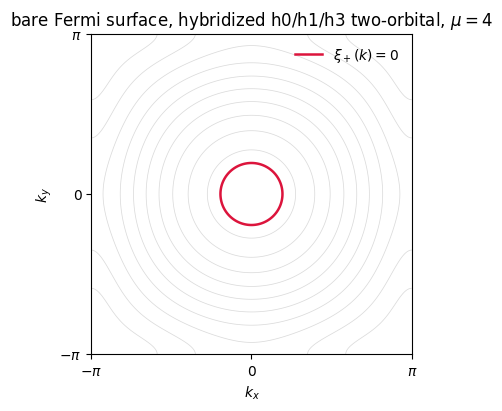

Building one-channel kernel K(p,k) ...

=== Results ===
model = Lieb lattice model
Nk = 51, Ntot = 2601
array memory for one-channel K [GB] = 0.054
channel constraint = odd_triplet
model = Lieb lattice model
h0(k) range = [-4.2000e+00, -3.8000e+00]
bare E_k range = [1.0000e-12, 4.0000e+00]
selected xi range = [-4.2000e+00, +2.0000e-01], min |xi| = 1.4546e-04
xi range = [-4.2000e+00, +1.9583e-01]
chi_pk model = continuum, xi_corr = 5.29, chi0 = 1, M_AM^2 = 9
Because Delta_tx and Delta_ty do not mix and use the same symmetry-constrained kernel here, each listed eigenvalue is exactly two-fold channel-degenerate.

Channel-constrained eigenvalues
-------------------------------
mode  Re(lambda)     Im(lambda)  constraint 
----  -------------  ----------  -----------
1     +2.072424e-01  +0.00e+00   odd_triplet
2     +2.072424e-01  +0.00e+00   odd_triplet
3     +1.382378e-01  +0.00e+00   odd_triplet
4     +1.382378e-01  +0.00e+00   odd_triplet
5     +1.189892e-01  +0.00e+00   odd_triplet
6  

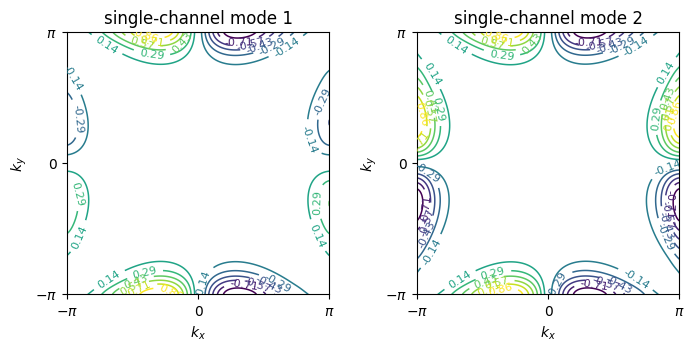

In [27]:
def run_pipeline(p: GapParams, make_plots=True, make_fermi_surface_plot=True, mode_numbers=(1, 2), channel_constraint=None, show_unconstrained_audit=True, top_basis_per_mode=5):
    if make_fermi_surface_plot:
        plot_fermi_surface_no_order(p)
        plt.show()

    K, grid_data = build_single_channel_kernel(p, verbose=True)
    x, y, qx, qy, vqx, vqy, h0v, dxv, dzv, Ev, xiv, fv, pref = grid_data
    if channel_constraint is None:
        channel_constraint = p.channel_constraint
    evals, evecs, channel_data = solve_channel_eigenproblem(K, p, constraint=channel_constraint)
    if show_unconstrained_audit:
        if channel_constraint != "unconstrained":
            audit_evals, audit_evecs = solve_eigenproblem(K, p)
        else:
            audit_evals, audit_evecs = evals, evecs
    else:
        audit_evals, audit_evecs = evals, evecs

    dx_grid = dxv.reshape(p.Nk, p.Nk)
    dz_grid = dzv.reshape(p.Nk, p.Nk)
    rows = []
    for i, val in enumerate(evals[: min(len(evals), 8)], start=1):
        rows.append([str(i), f"{np.real(val):+.6e}", f"{np.imag(val):+.2e}", channel_constraint])

    print("\n=== Results ===")
    print(f"model = {model_label(p)}")
    print(f"Nk = {p.Nk}, Ntot = {p.Nk ** 2}")
    print(f"array memory for one-channel K [GB] = {K.nbytes / 1e9:.3f}")
    print(f"channel constraint = {channel_constraint}")
    print_band_diagnostics(p)
    print(f"xi range = [{xiv.min():+.4e}, {xiv.max():+.4e}]")
    print(f"chi_pk model = {p.chi_model}, xi_corr = {p.xi_corr:.4g}, chi0 = {p.chi0:.4g}, M_AM^2 = {p.M_AM ** 2:.4g}")
    print("Because Delta_tx and Delta_ty do not mix and use the same symmetry-constrained kernel here, each listed eigenvalue is exactly two-fold channel-degenerate.")
    print()
    print_table("Channel-constrained eigenvalues", ["mode", "Re(lambda)", "Im(lambda)", "constraint"], rows)
    if show_unconstrained_audit:
        print()
        print_table(
            "Unconstrained scalar-mode parity audit",
            ["mode", "Re(lambda)", "parity", "even weight", "odd weight", "residual"],
            parity_rows(audit_evals, audit_evecs, p.Nk, num_modes=min(8, audit_evecs.shape[1])),
        )
    print()
    print_table(
        f"Channel-constrained harmonic overlaps, top {top_basis_per_mode} per mode",
        ["mode", "rank", "basis", "coeff", "overlap", "abs overlap"],
        mode_projection_rows(evecs, qx, qy, dx_grid, dz_grid, p.Nk, num_modes=min(2, evecs.shape[1]), top_per_mode=top_basis_per_mode, component_labels=orbital_component_labels(p)),
    )

    if p.save_outputs:
        np.save("example_gap_kernel_one_channel.npy", K)
        np.save("example_gap_evals_channel_constrained.npy", evals)
        np.save("example_gap_evecs_channel_constrained.npy", evecs)
        if show_unconstrained_audit:
            np.save("example_gap_evals_unconstrained_audit.npy", audit_evals)
            np.save("example_gap_evecs_unconstrained_audit.npy", audit_evecs)
        print("\nSaved:")
        print("  example_gap_kernel_one_channel.npy")
        print("  example_gap_evals_channel_constrained.npy")
        print("  example_gap_evecs_channel_constrained.npy")
        if show_unconstrained_audit:
            print("  example_gap_evals_unconstrained_audit.npy")
            print("  example_gap_evecs_unconstrained_audit.npy")

    if make_plots:
        plot_modes(
            evecs,
            x,
            y,
            p.Nk,
            mode_numbers=mode_numbers,
            num_levels=13,
            plot_grid_points=301,
            zero_tol=1e-10,
            zero_level_tol=1e-8,
        )
        plt.show()

    return {
        "params": p,
        "kernel_one_channel": K,
        "evals_channel_constrained": evals,
        "evecs_channel_constrained": evecs,
        "channel_data": channel_data,
        "evals_unconstrained_audit": audit_evals,
        "evecs_unconstrained_audit": audit_evecs,
        "grid": grid_data,
    }


# Edit params above, then run this cell.  For mu = 1.5, start with mode_numbers=(1, 2).
results = run_pipeline(params, make_plots=True, make_fermi_surface_plot=True, mode_numbers=(1, 2))


## Temperature Scan And Tc Estimate

For a fixed set of band and interaction parameters, the transition temperature is estimated from the linearized-gap criterion

$$\lambda_{max}(T_c)=1.$$

At each temperature, the code rebuilds the kernel through the temperature-dependent factor

$$F(\mathbf{k},T)=\frac{\tanh[\xi_n(\mathbf{k})/(2T)]}{2\xi_n(\mathbf{k})},$$

then solves for the leading eigenvalue $\lambda_{max}(T)$. If two neighboring temperatures $T_L<T_R$ bracket the crossing, meaning

$$[\lambda_{max}(T_L)-1][\lambda_{max}(T_R)-1]<0,$$

the reported estimate uses linear interpolation:

$$T_c=T_L+\frac{1-\lambda_{max}(T_L)}{\lambda_{max}(T_R)-\lambda_{max}(T_L)}(T_R-T_L).$$

This is a coarse estimate. For a final value, rerun the scan on a narrower temperature window around the bracket with a smaller `dT`.

For the pure spin-triplet interpretation, use `constraint="odd_triplet"` so that $\lambda_{max}$ is selected from the odd-parity scalar subspace rather than from the unconstrained scalar kernel.


model = Lieb lattice model
h0(k) range = [-4.2000e+00, -3.8000e+00]
bare E_k range = [1.0000e-12, 4.0000e+00]
selected xi range = [-4.2000e+00, +2.0000e-01], min |xi| = 1.4546e-04
constraint = odd_triplet
[01/40] T = 0.00500
[02/40] T = 0.01000


[03/40] T = 0.01500
[04/40] T = 0.02000
[05/40] T = 0.02500
[06/40] T = 0.03000
[07/40] T = 0.03500
[08/40] T = 0.04000
[09/40] T = 0.04500
[10/40] T = 0.05000
[11/40] T = 0.05500
[12/40] T = 0.06000
[13/40] T = 0.06500
[14/40] T = 0.07000
[15/40] T = 0.07500
[16/40] T = 0.08000
[17/40] T = 0.08500
[18/40] T = 0.09000
[19/40] T = 0.09500
[20/40] T = 0.10000
[21/40] T = 0.10500
[22/40] T = 0.11000
[23/40] T = 0.11500
[24/40] T = 0.12000
[25/40] T = 0.12500
[26/40] T = 0.13000
[27/40] T = 0.13500
[28/40] T = 0.14000
[29/40] T = 0.14500
[30/40] T = 0.15000
[31/40] T = 0.15500
[32/40] T = 0.16000
[33/40] T = 0.16500
[34/40] T = 0.17000
[35/40] T = 0.17500
[36/40] T = 0.18000
[37/40] T = 0.18500
[38/40] T = 0.19000
[39/40] T = 0.19500
[40/40] T = 0.20000
Temperature scan
----------------
T        Re(lambda_max)  Im(lambda_max)  lambda-target
-------  --------------  --------------  -------------
0.00500  0.207261        +0.00e+00       -0.792739    
0.01000  0.207255        +0.00e+00       

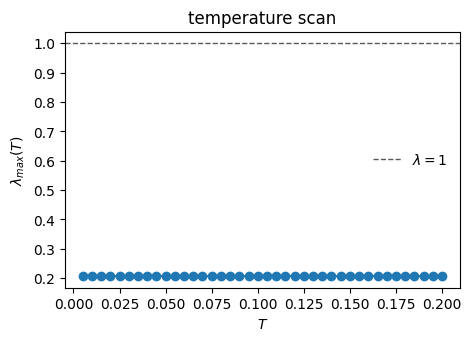

In [28]:
def clone_params(p: GapParams, **updates):
    data = p.__dict__.copy()
    data.update(updates)
    return GapParams(**data)


def make_temperature_grid(T_min=0.005, T_max=0.2, dT=0.005):
    return np.round(np.arange(T_min, T_max + 0.5 * dT, dT), 12)


def solve_leading_lambda_only(p: GapParams, verbose=False, constraint=None):
    if constraint is None:
        constraint = p.channel_constraint
    scan_p = clone_params(p, save_outputs=False, num_eigs=max(2, min(p.num_eigs, 4)))
    K, _ = build_single_channel_kernel(scan_p, verbose=verbose)
    evals, _, _ = solve_channel_eigenproblem(K, scan_p, constraint=constraint)
    leading = evals[0]
    return {
        "T": scan_p.T,
        "constraint": constraint,
        "lambda": leading,
        "lambda_real": float(np.real(leading)),
        "lambda_imag": float(np.imag(leading)),
    }


def estimate_lambda_crossing(scan_results, target=1.0, tol=1e-12):
    ordered = sorted(scan_results, key=lambda item: item["T"])
    for left, right in zip(ordered[:-1], ordered[1:]):
        y_left = left["lambda_real"] - target
        y_right = right["lambda_real"] - target

        if abs(y_left) < tol:
            return {"Tc": left["T"], "left": left, "right": left, "method": "grid point"}
        if y_left * y_right < 0:
            T_left, T_right = left["T"], right["T"]
            lam_left, lam_right = left["lambda_real"], right["lambda_real"]
            Tc = T_left + (target - lam_left) * (T_right - T_left) / (lam_right - lam_left)
            return {"Tc": float(Tc), "left": left, "right": right, "method": "linear interpolation"}
    return None


def scan_temperature_lambda(p: GapParams, temperatures=None, target=1.0, verbose=True, constraint=None):
    if temperatures is None:
        temperatures = make_temperature_grid(0.005, 0.2, 0.005)
    if constraint is None:
        constraint = p.channel_constraint

    print_band_diagnostics(p)
    print(f"constraint = {constraint}")

    scan_results = []
    table_rows = []
    for idx, T in enumerate(temperatures, start=1):
        if verbose:
            print(f"[{idx:02d}/{len(temperatures):02d}] T = {T:.5f}")

        pT = clone_params(p, T=float(T), save_outputs=False, num_eigs=max(2, min(p.num_eigs, 4)))
        item = solve_leading_lambda_only(pT, verbose=False, constraint=constraint)
        scan_results.append(item)
        table_rows.append([
            f"{item['T']:.5f}",
            f"{item['lambda_real']:.6f}",
            f"{item['lambda_imag']:+.2e}",
            f"{item['lambda_real'] - target:+.6f}",
        ])

    print_table(
        "Temperature scan",
        ["T", "Re(lambda_max)", "Im(lambda_max)", "lambda-target"],
        table_rows,
    )

    crossing = estimate_lambda_crossing(scan_results, target=target)
    if crossing is None:
        values = [item["lambda_real"] for item in scan_results]
        if all(value > target for value in values):
            print(f"No crossing bracketed: lambda_max(T) > {target:g} throughout this grid, so Tc is above the largest scanned T.")
        elif all(value < target for value in values):
            print(f"No crossing bracketed: lambda_max(T) < {target:g} throughout this grid, so Tc is below the smallest scanned T or absent for these parameters.")
        else:
            print(f"No crossing of lambda = {target:g} was bracketed on this temperature grid.")
    else:
        left = crossing["left"]
        right = crossing["right"]
        print(
            f"Estimated Tc = {crossing['Tc']:.6f} by {crossing['method']} "
            f"between T={left['T']:.5f} and T={right['T']:.5f}."
        )

    return scan_results, crossing


def plot_temperature_scan(scan_results, crossing=None, target=1.0):
    ordered = sorted(scan_results, key=lambda item: item["T"])
    temperatures = np.array([item["T"] for item in ordered], dtype=float)
    lambdas = np.array([item["lambda_real"] for item in ordered], dtype=float)

    fig, ax = plt.subplots(figsize=(4.6, 3.3), constrained_layout=True)
    ax.plot(temperatures, lambdas, marker="o", linewidth=1.4)
    ax.axhline(target, color="0.35", linestyle="--", linewidth=1.0, label=rf"$\lambda={target:g}$")
    if crossing is not None:
        ax.axvline(crossing["Tc"], color="crimson", linestyle=":", linewidth=1.3, label=rf"$T_c={crossing['Tc']:.4g}$")
    ax.set_xlabel(r"$T$")
    ax.set_ylabel(r"$\lambda_{max}(T)$")
    ax.set_title(r"temperature scan")
    ax.legend(frameon=False)
    return fig


temperature_scan_grid = make_temperature_grid(0.005, 0.2, 0.005)
run_temperature_scan = True

if run_temperature_scan:
    temperature_scan_params = clone_params(params, save_outputs=False, num_eigs=2)
    temperature_scan_results, temperature_crossing = scan_temperature_lambda(
        temperature_scan_params,
        temperatures=temperature_scan_grid,
        target=1.0,
        verbose=True,
        constraint="odd_triplet",
    )
    plot_temperature_scan(temperature_scan_results, temperature_crossing, target=1.0)
    plt.show()
else:
    print("Temperature scan is defined but not run. Set run_temperature_scan = True to estimate Tc from lambda_max(T)=1.")
